In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive - Richfield Graduate Institute of Technology\Desktop\Support-Ticket-Classification-Model\data\all_tickets.csv")
print(df.shape)
df.head()

(48549, 9)


,title,body,ticket_type,category,sub_category1,sub_category2,business_service,urgency,impact
0,NaN,hi since recruiter lead permission approve req...,1,4,2,21,71,3,4
1,connection with icon,icon dear please setup icon per icon engineers...,1,6,22,7,26,3,4
2,work experience user,work experience user hi work experience studen...,1,5,13,7,32,3,4
3,requesting for meeting,requesting meeting hi please help follow equip...,1,5,13,7,32,3,4
4,reset passwords for external accounts,re expire days hi ask help update passwords co...,1,4,2,76,4,3,4


In [4]:
#NULLS AND LABEL DISTRIBUTION
print(df.isnull().sum())
print()
print('ticket_type counts:', df['ticket_type'].value_counts().to_dict())
print('category unique values:', df['category'].nunique())
print('urgency counts:', df['urgency'].value_counts().to_dict())

title               712
body                  0
ticket_type           0
category              0
sub_category1         0
sub_category2         0
business_service      0
urgency               0
impact                0
dtype: int64

ticket_type counts: {1: 34621, 0: 13928}
category unique values: 13
urgency counts: {3: 34621, 1: 6748, 2: 5528, 0: 1652}


In [5]:
#NOTE: category and urgency are anonymized integer codes in the source data (the
#provider stripped the real label names). Category is used as-is (Category 1-13).
#Urgency only varies meaningfully within ticket_type == 0 (the other segment is 100%
#a single urgency value), so priority is modeled on that subset and mapped to
#Low/Medium/High to match the task's required priority scale.

df['category_label'] = 'Category ' + df['category'].astype(str)

priority_df = df[df['ticket_type'] == 0].copy()
urgency_to_priority = {0: 'Low', 1: 'Medium', 2: 'High'}
priority_df['priority_label'] = priority_df['urgency'].map(urgency_to_priority)

print(priority_df['priority_label'].value_counts())

priority_label
Medium    6748
High      5528
Low       1652
Name: count, dtype: int64


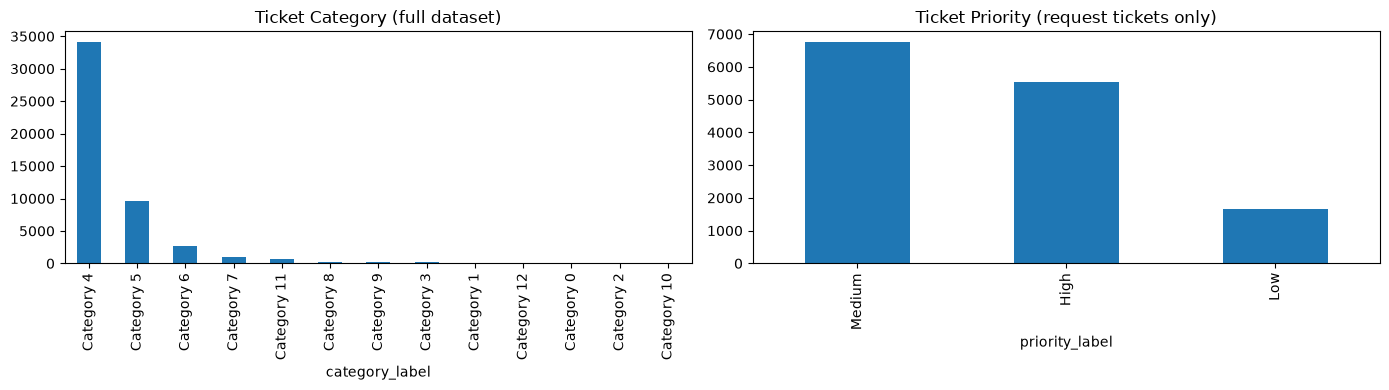

In [6]:
#CLASS BALANCE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['category_label'].value_counts().plot(kind='bar', ax=axes[0], title='Ticket Category (full dataset)')
priority_df['priority_label'].value_counts().plot(kind='bar', ax=axes[1], title='Ticket Priority (request tickets only)')
plt.tight_layout()
plt.show()

In [7]:
#TEXT CLEANING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = (df['title'].fillna('') + ' ' + df['body'].fillna('')).apply(clean_text)
priority_df['clean_text'] = (priority_df['title'].fillna('') + ' ' + priority_df['body'].fillna('')).apply(clean_text)
df[['title', 'clean_text']].head(3)

,title,clean_text
0,NaN,hi since recruiter lead permission approve req...
1,connection with icon,connection with icon icon dear please setup ic...
2,work experience user,work experience user work experience user hi w...


In [8]:
#MODEL 1 - CATEGORY CLASSIFIER (full dataset)
category_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_cat = category_vectorizer.fit_transform(df['clean_text'])
y_cat = df['category_label']

Xcat_train, Xcat_test, ycat_train, ycat_test = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

category_model = LogisticRegression(max_iter=1000, class_weight='balanced')
category_model.fit(Xcat_train, ycat_train)
cat_pred = category_model.predict(Xcat_test)

print(f'Category accuracy: {accuracy_score(ycat_test, cat_pred):.4f}')
print(f'Category macro F1: {f1_score(ycat_test, cat_pred, average="macro"):.4f}')
print(classification_report(ycat_test, cat_pred))

Category accuracy: 0.7904
Category macro F1: 0.4159
              precision    recall  f1-score   support

  Category 0       0.00      0.00      0.00         1
  Category 1       0.03      0.29      0.06        14
 Category 11       0.40      0.73      0.52       123
 Category 12       0.33      0.67      0.44         9
  Category 2       0.00      0.00      0.00         1
  Category 3       0.08      0.44      0.13        27
  Category 4       0.96      0.81      0.88      6812
  Category 5       0.79      0.75      0.77      1927
  Category 6       0.36      0.75      0.49       526
  Category 7       0.47      0.91      0.62       184
  Category 8       0.57      0.81      0.67        48
  Category 9       0.29      0.74      0.42        38

    accuracy                           0.79      9710
   macro avg       0.36      0.57      0.42      9710
weighted avg       0.87      0.79      0.82      9710



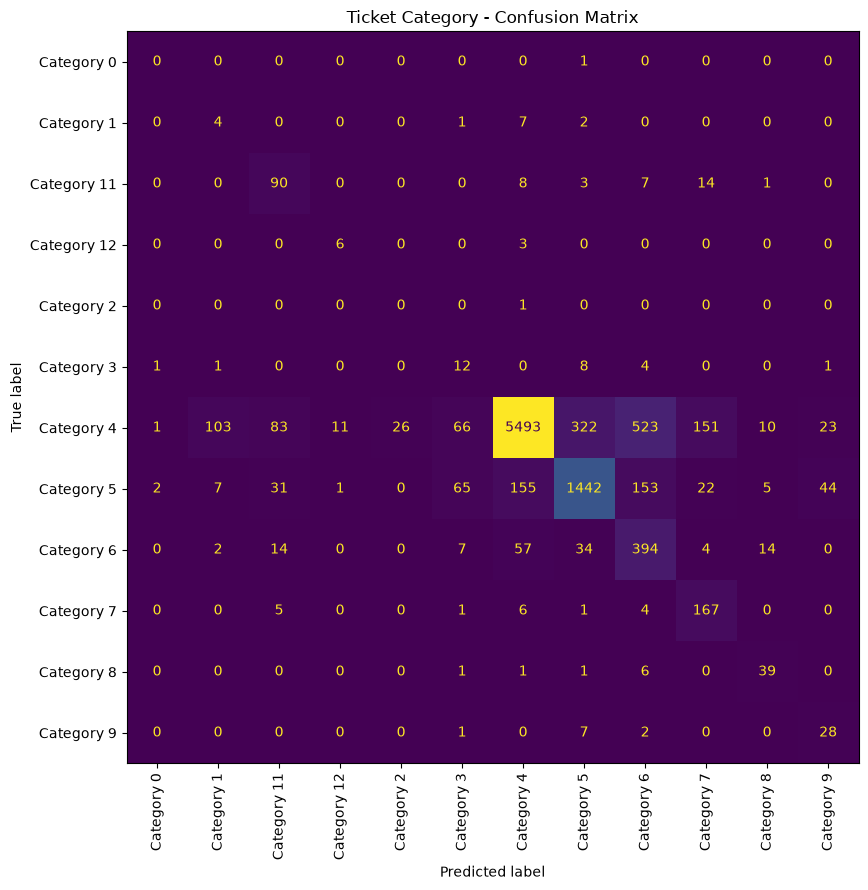

In [9]:
#CATEGORY CONFUSION MATRIX
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay.from_predictions(ycat_test, cat_pred, xticks_rotation=90, ax=ax, colorbar=False)
ax.set_title('Ticket Category - Confusion Matrix')
plt.tight_layout()
plt.show()

In [10]:
#MODEL 2 - PRIORITY CLASSIFIER (request-type tickets only, own TF-IDF vectorizer)
priority_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_pri = priority_vectorizer.fit_transform(priority_df['clean_text'])
y_pri = priority_df['priority_label']

Xpri_train, Xpri_test, ypri_train, ypri_test = train_test_split(
    X_pri, y_pri, test_size=0.2, random_state=42, stratify=y_pri
)

priority_model = LogisticRegression(max_iter=1000, class_weight='balanced')
priority_model.fit(Xpri_train, ypri_train)
pri_pred = priority_model.predict(Xpri_test)

print(f'Priority accuracy: {accuracy_score(ypri_test, pri_pred):.4f}')
print(f'Priority macro F1: {f1_score(ypri_test, pri_pred, average="macro"):.4f}')
print(classification_report(ypri_test, pri_pred))

Priority accuracy: 0.5729
Priority macro F1: 0.5497
              precision    recall  f1-score   support

        High       0.61      0.57      0.59      1106
         Low       0.35      0.66      0.46       330
      Medium       0.67      0.55      0.60      1350

    accuracy                           0.57      2786
   macro avg       0.54      0.59      0.55      2786
weighted avg       0.61      0.57      0.58      2786



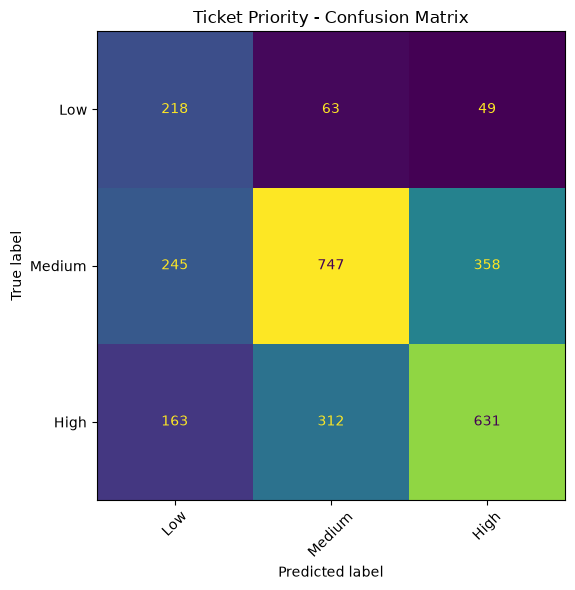

In [11]:
#PRIORITY CONFUSION MATRIX
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(ypri_test, pri_pred, xticks_rotation=45, ax=ax, colorbar=False,
                                          labels=['Low', 'Medium', 'High'])
ax.set_title('Ticket Priority - Confusion Matrix')
plt.tight_layout()
plt.show()

In [12]:
#TICKET CLASSIFICATION SYSTEM - PREDICTS CATEGORY FOR ANY TICKET, PLUS PRIORITY FOR REQUEST-TYPE TICKETS
def classify_ticket(title, body, is_request_type=True):
    text = clean_text((title or '') + ' ' + (body or ''))

    cat_features = category_vectorizer.transform([text])
    predicted_category = category_model.predict(cat_features)[0]

    predicted_priority = None
    if is_request_type:
        pri_features = priority_vectorizer.transform([text])
        predicted_priority = priority_model.predict(pri_features)[0]

    return predicted_category, predicted_priority

example_title = "cannot access shared drive"
example_body = "hi team i am unable to access the shared network drive since this morning please help urgently"

predicted_category, predicted_priority = classify_ticket(example_title, example_body, is_request_type=True)
print(f'Predicted category: {predicted_category}')
print(f'Predicted priority: {predicted_priority}')

Predicted category: Category 6
Predicted priority: Low
